#Machine Learning Assignment
##Linear Regression Model Using the Diabetes Dataset

###Objective
The objective of this project is to build and deploy a Linear Regression model using the Diabetes Dataset from scikit-learn. 

The project includes:
- Dataset understanding
- Exploratory Data Analysis (EDA)
- Data visualization
- Model building
- Model evaluation
- Model deployment using a web application
- Communicating insights through a technical report

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes

In [5]:
# Load the diabetes dataset
diabetes = load_diabetes()

# Convert to pandas DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Add the target column
df['target'] = diabetes.target

# Display first 10 rows
df.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


In [6]:
# Dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (442, 11)


In [7]:
print("Feature Names:")
print (diabetes.feature_names)

Feature Names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [8]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [9]:
# Display target variable
df['target'].head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

#Target Variable

The target variable in this dataset is **target**.

This variable represents a quantitative measure of disease progression in diabetes patients one year after baseline.

#Why it is suitable for Linear Regression

The target variable is continuous numeric data. Since Linear Regression is used to predict continuous values, this makes the dataset appropriate for a regression problem.

In [10]:
#Task 2: Exploratory Data Analysis (EDA)
df.shape
df.dtypes

age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

In [11]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [12]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
print("Mean:\n", df.mean())
print("\nMedian:\n", df.median())
print("\nStandard Deviation:\n", df.std())

Mean:
 age      -1.444295e-18
sex       2.543215e-18
bmi      -2.255925e-16
bp       -4.854086e-17
s1       -1.428596e-17
s2        3.898811e-17
s3       -6.028360e-18
s4       -1.788100e-17
s5        9.168131e-17
s6        1.351770e-17
target    1.521335e+02
dtype: float64

Median:
 age         0.005383
sex        -0.044642
bmi        -0.007284
bp         -0.005670
s1         -0.004321
s2         -0.003819
s3         -0.006584
s4         -0.002592
s5         -0.001947
s6         -0.001078
target    140.500000
dtype: float64

Standard Deviation:
 age        0.047619
sex        0.047619
bmi        0.047619
bp         0.047619
s1         0.047619
s2         0.047619
s3         0.047619
s4         0.047619
s5         0.047619
s6         0.047619
target    77.093005
dtype: float64


In [15]:
correlation = df.corr()
correlation

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


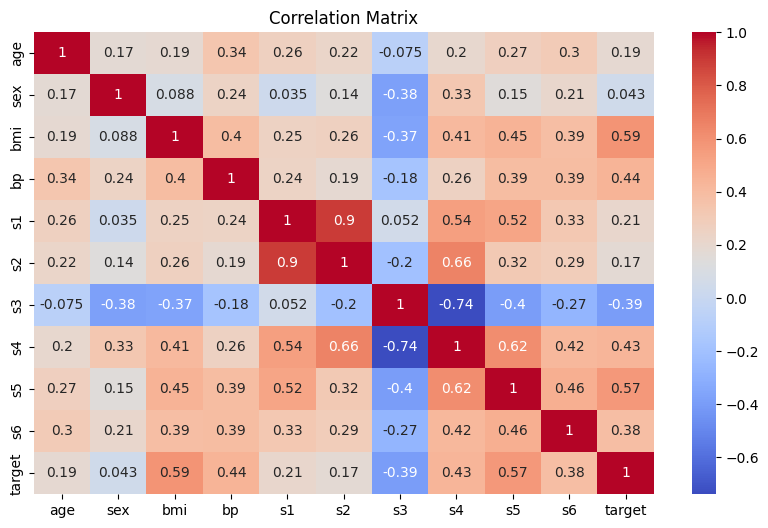

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [17]:
correlation['target'].sort_values(ascending=False)

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64

#Feature Relationship with Target

From the correlation analysis, some variables show a stronger relationship with the target variable.

Key influencing features include:
- BMI
- Blood Pressure (bp)
- s5 (serum measurement)

These features have higher correlation values with the target variable, indicating they may significantly influence diabetes disease progression.

#Task 3: Data Visualization

Data visualization helps in understanding patterns, trends, and relationships within the dataset. 
This section includes univariate, bivariate, and multivariate visualizations.

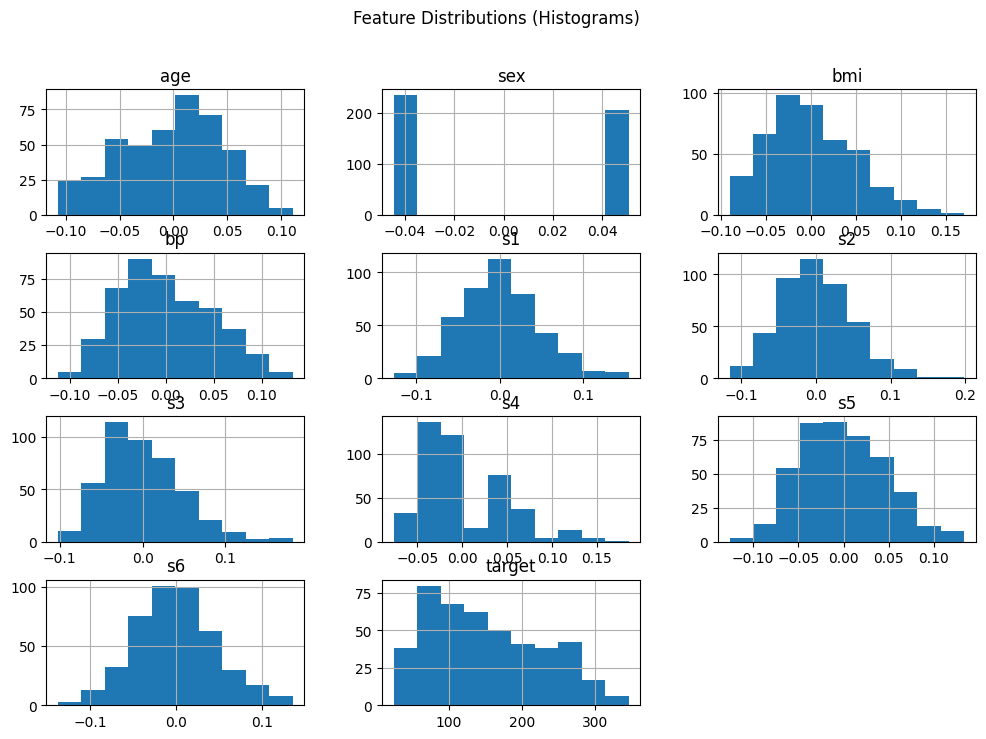

In [18]:
df.hist(figsize=(12,8))
plt.suptitle("Feature Distributions (Histograms)")
plt.show()

#Interpretation
The histograms show the distribution of each feature in the dataset. 
Most variables appear normally distributed since the dataset has been standardized.
This helps identify the spread and central tendency of the variables.

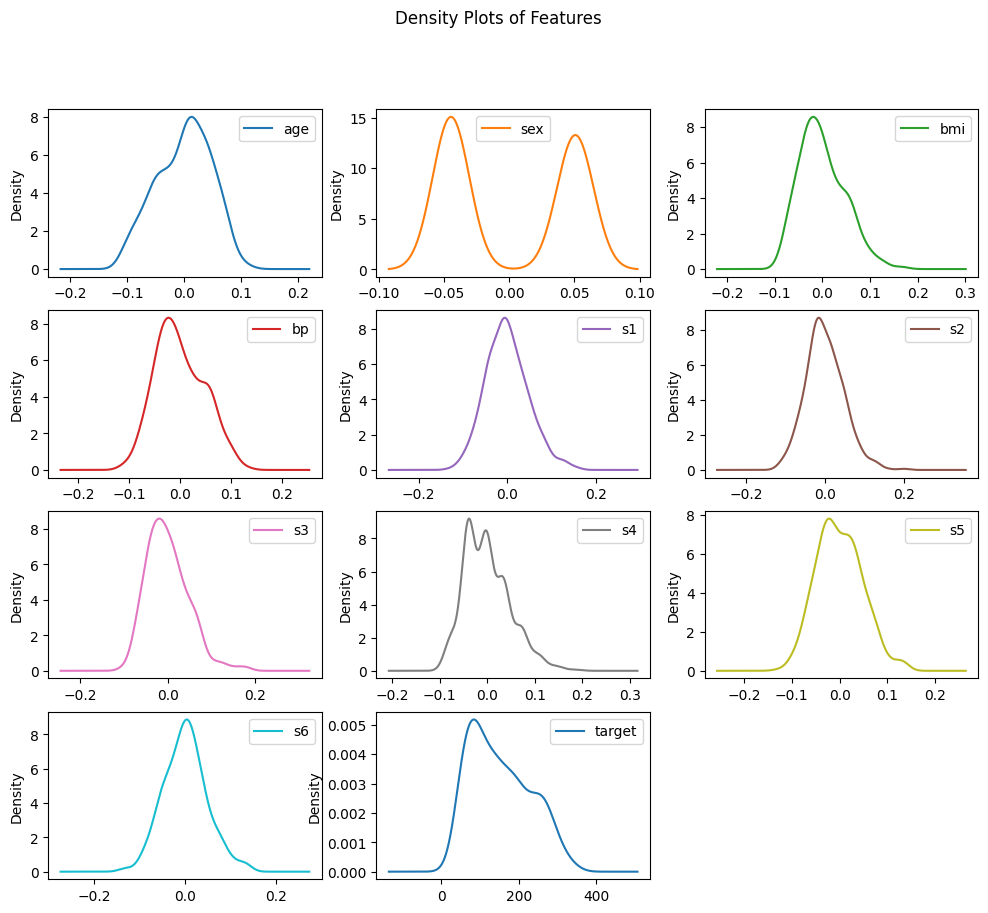

In [19]:
df.plot(kind='density', subplots=True, layout=(4,3), figsize=(12,10), sharex=False)
plt.suptitle("Density Plots of Features")
plt.show()

#Interpretation
Density plots provide a smoother representation of the feature distributions. 
They help visualize where the values are concentrated and highlight the probability density of each feature.

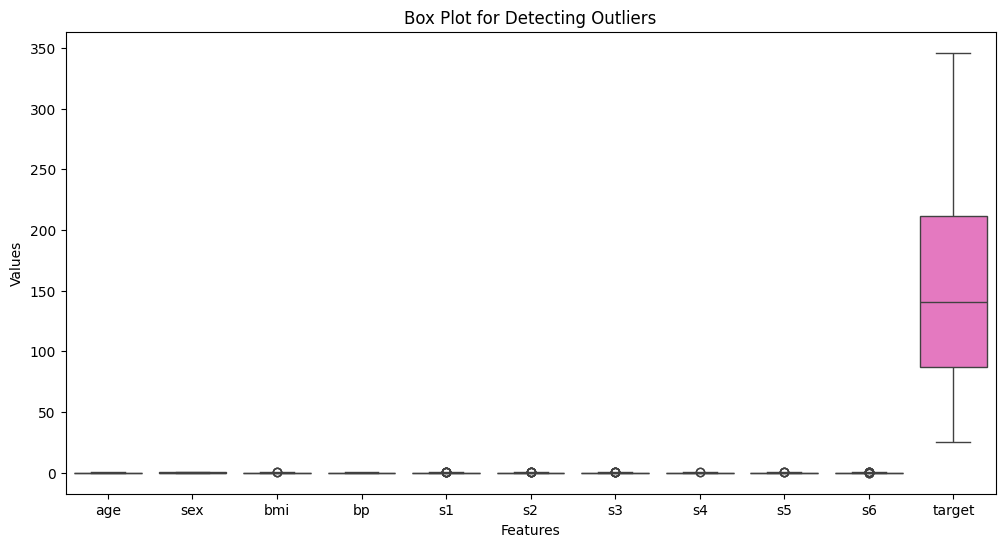

In [20]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Box Plot for Detecting Outliers")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

#Interpretation
Box plots help identify the presence of outliers in the dataset. 
Some variables show points outside the whiskers which indicate potential outliers.
Outliers can affect regression performance and may require treatment.

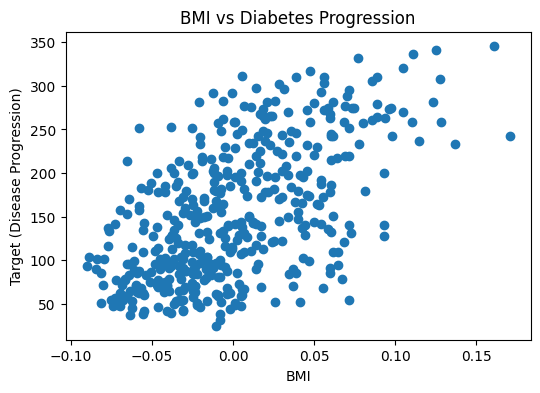

In [21]:
plt.figure(figsize=(6,4))
plt.scatter(df['bmi'], df['target'])
plt.title("BMI vs Diabetes Progression")
plt.xlabel("BMI")
plt.ylabel("Target (Disease Progression)")
plt.show()

#Interpretation
The scatter plot shows the relationship between BMI and diabetes progression.
There appears to be a positive relationship, suggesting that higher BMI values are associated with higher disease progression scores.

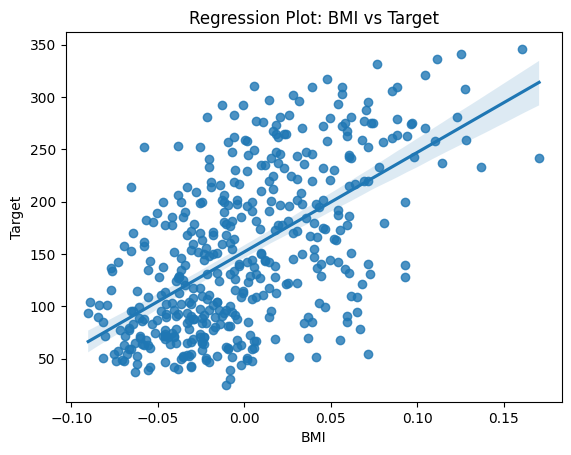

In [22]:
sns.regplot(x='bmi', y='target', data=df)
plt.title("Regression Plot: BMI vs Target")
plt.xlabel("BMI")
plt.ylabel("Target")
plt.show()

#Interpretation
The regression plot confirms a positive linear relationship between BMI and the target variable.
This indicates that BMI may be a strong predictor for the regression model.

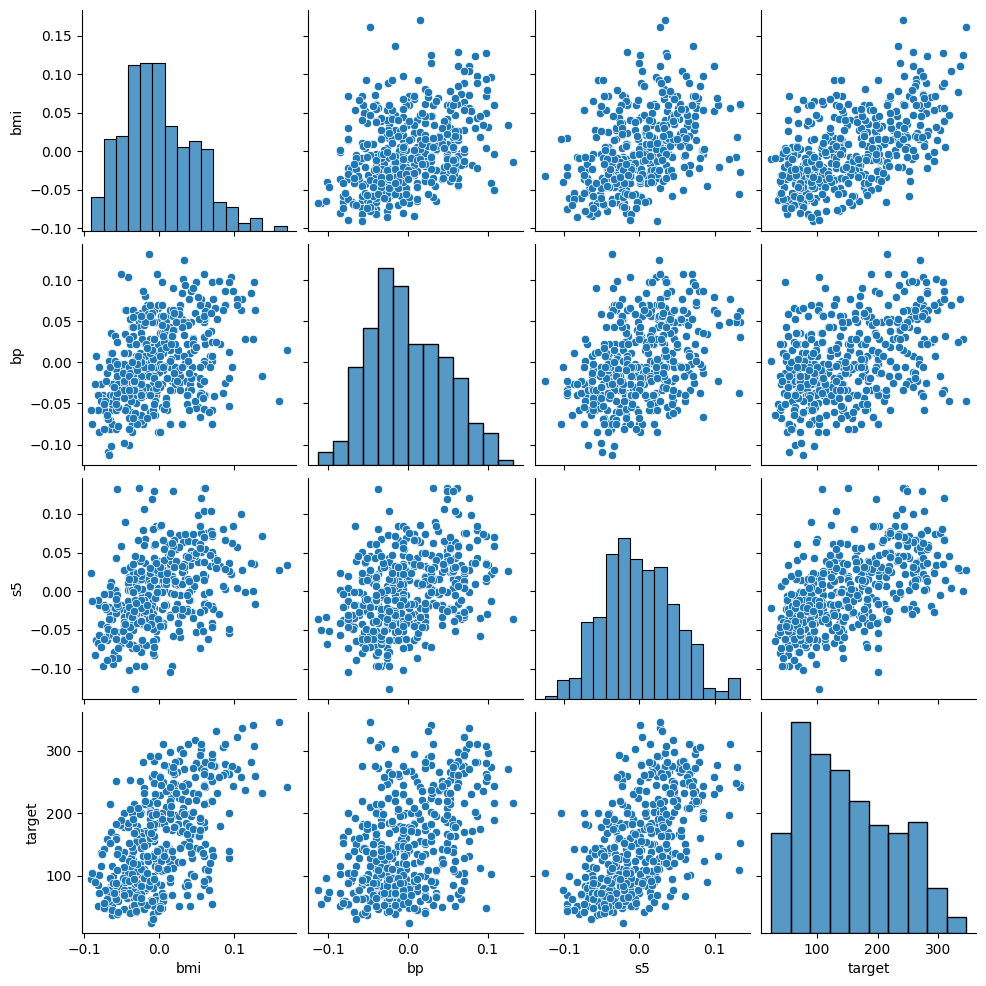

In [23]:
sns.pairplot(df[['bmi','bp','s5','target']])
plt.show()

#Interpretation
Pair plots visualize pairwise relationships between selected variables.
The plots show how BMI, blood pressure, and serum measurements relate to the target variable.
Some variables display moderate linear relationships with the target.

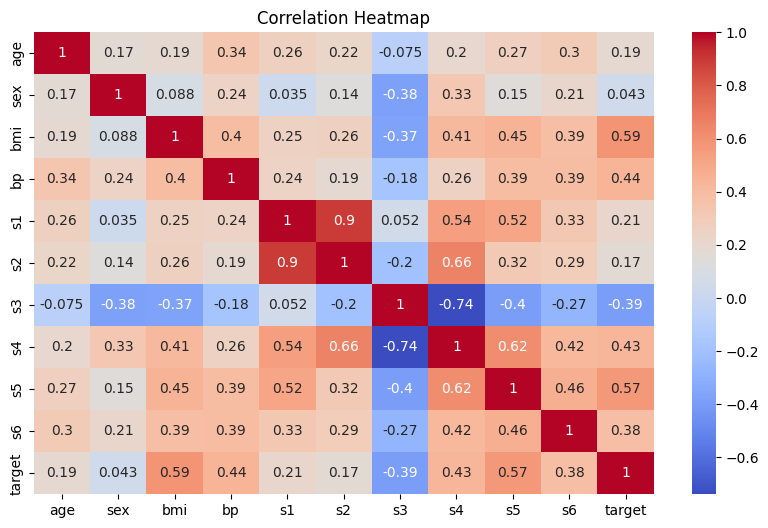

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#Interpretation
The heatmap shows correlations between variables.
Features such as BMI, BP, and S5 show stronger correlations with the target variable.
These features are likely important predictors in the regression model.

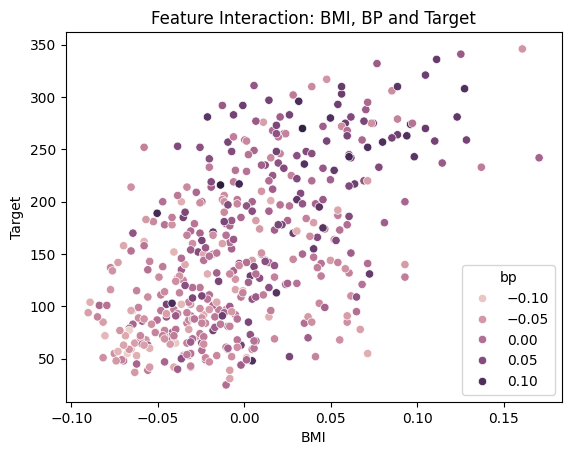

In [25]:
sns.scatterplot(x='bmi', y='target', hue='bp', data=df)
plt.title("Feature Interaction: BMI, BP and Target")
plt.xlabel("BMI")
plt.ylabel("Target")
plt.show()

#Interpretation
This plot shows the interaction between BMI, blood pressure, and the target variable.
It indicates that both BMI and BP influence diabetes progression.

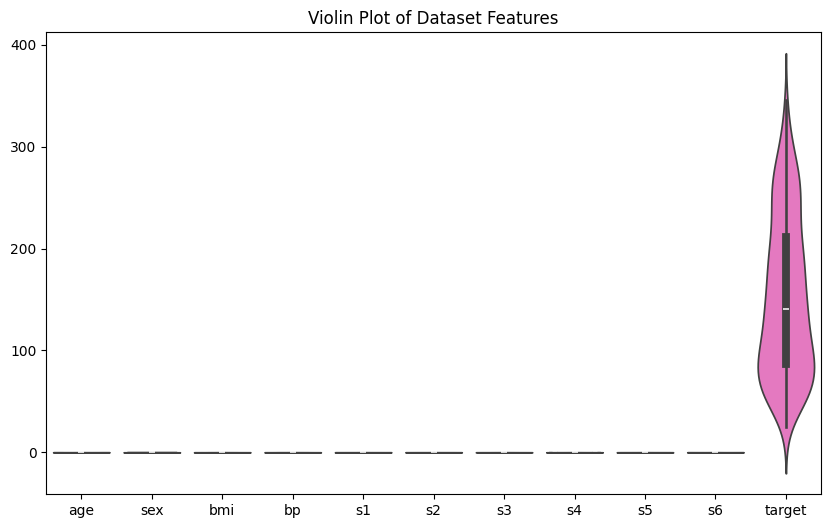

In [26]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df)
plt.title("Violin Plot of Dataset Features")
plt.show()

#Interpretation
Violin plots combine box plots and density plots to show both distribution and spread of data.
They highlight variations in the dataset and potential outliers.

#Task 4: Data Preparation

Data preparation ensures that the dataset is suitable for machine learning algorithms.
This includes feature selection, splitting the data into training and testing sets, scaling features, and detecting outliers.

In [27]:
X = df.drop('target', axis=1)
y = df['target']

#Why Feature Selection is Necessary

Feature selection separates the independent variables (features) from the dependent variable (target).
This allows the machine learning model to learn how the features influence the target variable.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (353, 10)
Testing set size: (89, 10)


#Why Train-Test Split is Necessary

The dataset is divided into training and testing sets.

Training data (80%) is used to train the model.
Testing data (20%) is used to evaluate the model’s performance on unseen data.

This prevents overfitting and ensures the model generalizes well.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Why Feature Scaling is Necessary

Feature scaling standardizes the range of variables so that all features contribute equally to the model.

Without scaling, features with larger numerical ranges may dominate the model.

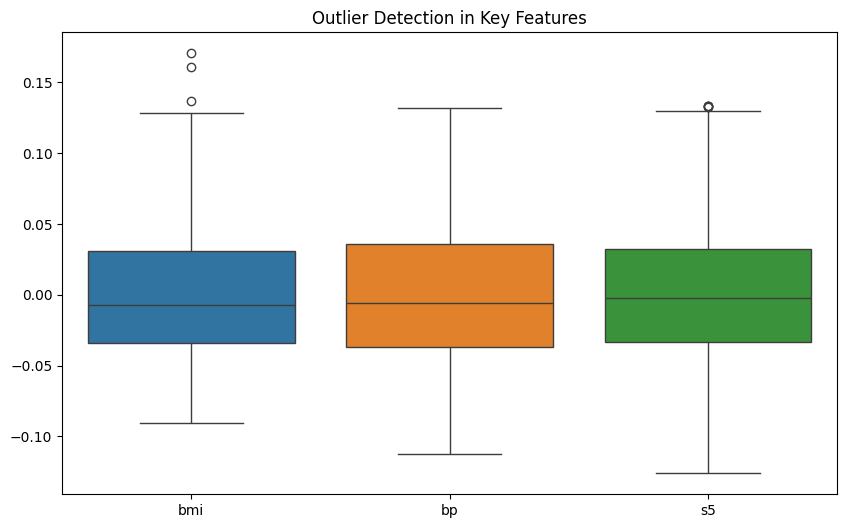

In [30]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['bmi','bp','s5']])
plt.title("Outlier Detection in Key Features")
plt.show()

#Why Outlier Detection is Necessary

Outliers are extreme values that differ significantly from other observations.

They can distort regression models and reduce prediction accuracy.
Identifying and treating outliers helps improve model reliability.

#Task 5: Model Development

In this section, a Linear Regression model is developed to predict diabetes disease progression using the selected features.
The model will be trained on the training dataset and evaluated using several regression evaluation metrics.

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# Display first predictions
y_pred[:10]

array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872,  92.1723465 , 258.23238899, 181.33732057,
        90.22411311, 108.63375858])

In [34]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 42.79409467959994
Mean Squared Error: 2900.193628493482
Root Mean Squared Error: 53.85344583676593
R² Score: 0.45260276297191937


#Model Performance Interpretation

Mean Absolute Error (MAE):
MAE represents the average absolute difference between predicted and actual values. 
A lower MAE indicates better model accuracy.

Mean Squared Error (MSE):
MSE measures the average squared difference between predicted and actual values. 
Large errors are penalized more heavily.

Root Mean Squared Error (RMSE):
RMSE is the square root of MSE and represents the model's prediction error in the same units as the target variable.

R² Score:
The R² score represents the proportion of variance in the target variable explained by the model.
An R² value closer to 1 indicates a better fit.

Overall, the Linear Regression model demonstrates a reasonable ability to predict diabetes disease progression using the available features.

#Task 6: Model Saving and Exporting

After training the model, it is saved so that it can be used later in a web application without retraining.

In [35]:
#saving the model with pickle
import pickle

# Save the trained model
with open("linear_regression_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
